# Robustness: finite-difference step, measurement noise, Fock cutoff, ridge, extended box, second device, new realizations, baselines

## Statement of the problem
Bound the claims of the main text: (i) is the finite-difference gradient stable in the step? (ii) does it survive measurement noise? (iii) is the Fock truncation converged at the optima? (iv) does the landscape depend on the assumed readout precision (ridge)? (v) are the boundary optima box artefacts? (vi) does a device that is already good gain anything? (vii) do the optima transfer to new input realizations? (viii) how does the reservoir compare with reservoir-free regressions and an echo-state network?

Scripts: `run_supp.py {fd,noise,fock,ridge,narma}` and `run_review.py {gap,baselines,box,seeds,refab,device2}`.

In [1]:
import os, sys, subprocess, numpy as np
CODE = os.path.abspath(os.path.join(os.getcwd(), '..', 'code')); sys.path.insert(0, CODE); os.chdir(CODE); os.environ['OMP_NUM_THREADS'] = '1'
import matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from common import *
import make_figs
RUN = False   # set True to recompute the data for this notebook (see the "Compute" section for the cost)
def show(pdf, dpi=110):
    """Render a figure PDF from paper/figs inline."""
    base = '/tmp/' + os.path.basename(pdf)[:-4]; subprocess.run(['pdftoppm', '-r', str(dpi), '-png', '-singlefile', pdf, base], check=True); display(Image(filename=base + '.png'))
def ld(name):
    p = os.path.join(DATA, name); return np.load(p, allow_pickle=True) if os.path.exists(p) else None


In [2]:
if RUN:
    for p in ('fd', 'fock', 'noise', 'narma', 'ridge'): subprocess.run(['python3', 'run_supp.py', p])
    for p in ('baselines', 'box', 'seeds', 'device2'): subprocess.run(['python3', 'run_review.py', p])
rv = ld('review.npz'); fd = ld('supp_fd.npz'); nz = ld('supp_noise.npz'); ng = ld('supp_noisygd.npz'); fk = ld('supp_fock.npz'); rd = ld('supp_ridge.npz')
print('FD step (mid-box anchor), gradient at h=1e-3 vs 1e-2:', fd['fd_mid'][fd['fd_h'] == 1e-3][0].round(5), fd['fd_mid'][fd['fd_h'] == 1e-2][0].round(5))
G0, Gn = nz['G0_mid'], nz['Gn_mid']; a = np.argmin(abs(nz['hs'] - 0.1)); b = np.argmin(abs(nz['sig'] - 0.01))
print('sign recovery at 1%% noise, h=0.1 (r, re, dth):', [np.mean(np.sign(Gn[a, b, :, i]) == np.sign(G0[a, i])) for i in range(3)])
print('noisy GD: median noiseless-loss reduction at 1%% noise: %.0f%%' % (100 * np.median(1 - ng['clean_0.01'] / ng['L0_clean'])))
print('Fock cutoff at the basin: L(Nc=8)/L(Nc=20) - 1 = %.1e' % (fk['fock_best_gd'][1, 1] / fk['fock_best_gd'][-1, 1] - 1))
from scipy.stats import spearmanr
print('ridge: rank correlation with 1%% landscape at sigma_rel =', dict(zip(rd['sigs'], [round(spearmanr(rd['L'][1].ravel(), rd['L'][a].ravel()).correlation, 2) for a in range(4)])))
for n in ('mg', 'narma', 'lorenz', 'nce'): print('baselines', n, [(r[0], round(float(r[2]), 3)) for r in rv[f'base_{n}']])
print('second device (T_in=4): best squeezing gain %.1f%%' % (100 * (1 - rv['dev2_L3'].min() / rv['dev2_L3'][0, 0, 0])))
for n in ('mg', 'narma', 'lorenz', 'nce'): S = rv[f'seeds_{n}']; print('transfer to new realizations', n, (100 * (1 - S[:, 1] / S[:, 0])).round(0))

FD step (mid-box anchor), gradient at h=1e-3 vs 1e-2: [ 1.716e-02 -1.210e-03  2.000e-05] [ 1.701e-02 -1.210e-03  2.000e-05]
sign recovery at 1%% noise, h=0.1 (r, re, dth): [np.float64(1.0), np.float64(0.83), np.float64(0.53)]
noisy GD: median noiseless-loss reduction at 1% noise: 21%
Fock cutoff at the basin: L(Nc=8)/L(Nc=20) - 1 = 1.5e-08


ridge: rank correlation with 1%% landscape at sigma_rel = {np.float64(0.003): np.float64(0.97), np.float64(0.01): np.float64(1.0), np.float64(0.03): np.float64(0.86), np.float64(0.1): np.float64(0.69)}
baselines mg [('ols4', 0.492), ('ols10', 0.435), ('quad10', 0.138), ('esn100', 0.006)]
baselines narma [('ols4', 0.854), ('ols10', 0.835), ('quad10', 0.894), ('esn100', 0.408)]
baselines lorenz [('ols4', 0.225), ('ols10', 0.173), ('quad10', 0.313), ('esn100', 0.028)]
baselines nce [('ols4', 0.189), ('ols10', 0.117), ('quad10', 0.1), ('esn100', 0.104)]
second device (T_in=4): best squeezing gain 0.0%
transfer to new realizations mg [33. 35.]
transfer to new realizations narma [18. 19.]
transfer to new realizations lorenz [11.  7.]
transfer to new realizations nce [94. 94.]


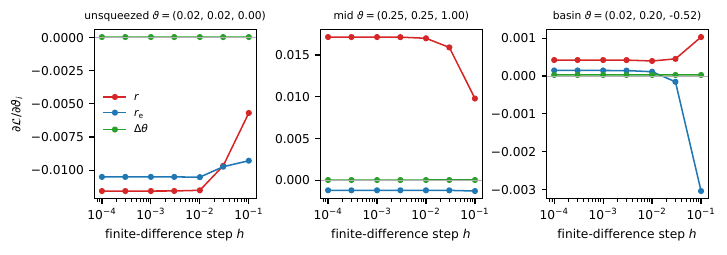

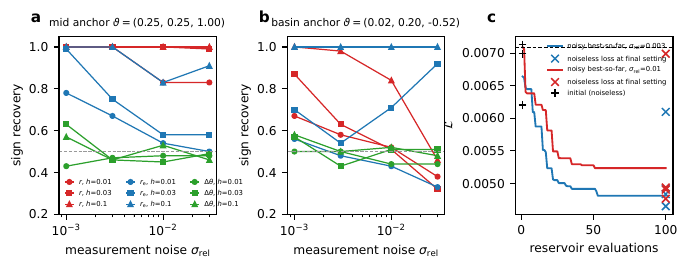

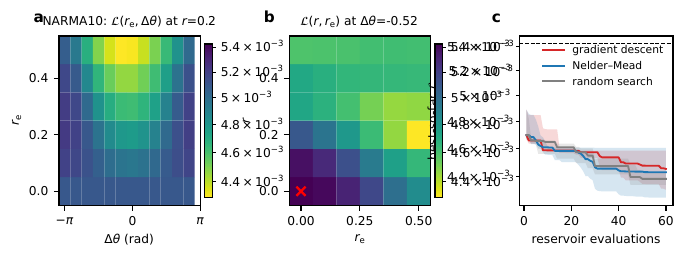

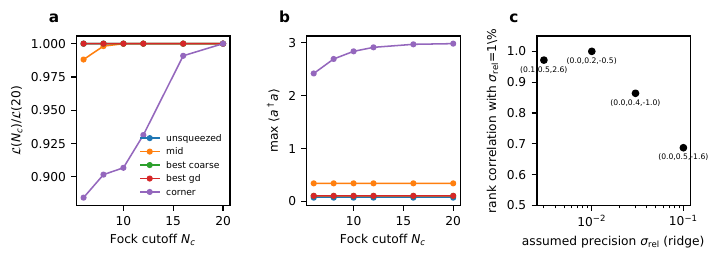

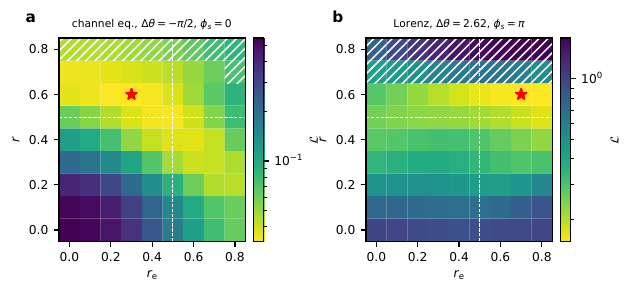

```latex
\begin{tabular}{lcccc}
\toprule
Method & Mackey--Glass & NARMA10 & Lorenz-63 & channel eq.\\
\midrule
unsqueezed reservoir & 0.521 & 0.965 & 0.201 & 0.491\\
squeezed reservoir & 0.431 & 0.840 & 0.191 & 0.127\\
squeezed, amplifying phase (Lorenz) & -- & -- & 0.147 & --\\
linear regression, 4 delays & 0.492 & 0.854 & 0.225 & 0.189\\
linear regression, 10 delays & 0.435 & 0.835 & 0.173 & 0.117\\
quadratic regression, 10 delays & 0.138 & 0.894 & 0.313 & 0.100\\
100-node echo-state network (tuned) & 0.006 & 0.408 & 0.028 & 0.104\\
\bottomrule
\end{tabular}
```

In [3]:
make_figs.figS1(); make_figs.figS2(ld('fig2_scans.npz')['L3'][0,0,0]); make_figs.figS3(); make_figs.figS4(); make_figs.figS_box(); make_figs.basetable()
for f in ('figS1_fd', 'figS2_noise', 'figS3_narma', 'figS4_fock_ridge', 'figS_box'): show(f'paper/figs/{f}.pdf')
display(Markdown('```latex\n' + open('paper/basetable.tex').read() + '\n```'))

The amplitude gradients survive 1% noise; the phase gradient (10–100× smaller) does not. The ridge moves the basin location with the assumed precision — an argument for in-situ training. A device already good for the task gains nothing. The squeezed reservoir matches linear regression on ten delays and is far from a tuned ESN: the contribution is control, not accuracy.